#BA 305 Project Notebook Data Cleaning Iteration 2

Welcome to our project notebook. For our dataset, we have worked on a steam games dataset. Each row represents a game with information about it that can be found on the game's page on steam.

##General Dataset Infromation##

##Information for each game

##Project Objective

##Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import *
%matplotlib inline
import matplotlib.pylab as plt

from sklearn import preprocessing
from sklearn.decomposition import PCA

import seaborn as sns



# mount google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **Data Pre-Processing**

When defining the dataset into a data frame some of the columns were misplaced, so we resolved the issue with the code below.

In [ ]:
#Define the dataframe
df = pd.read_csv('/content/drive/MyDrive/games.csv')
df.head()

#Rename the columns for data consistencty
steam_df = df.rename(columns = {'AppID' : 'Name', 'Name' : 'Release date', 'Release date' : 'Estimated owners',
'Estimated owners' : 'Peak CCU', 'Peak CCU' : 'Required age', 'Required age' : 'Price', 'Price' : 'Discount',
'DiscountDLC count' : 'DLC count'})


#Remove rows where both positive and negative columns are neagtive
steam_df = steam_df[~((steam_df['Positive'] == 0) & (steam_df['Negative'] == 0))]

#Force pandas to display all the columns
pd.set_option('display.max_columns', None)

#Show the head of the dataset
steam_df.head()

,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,Supported languages,Full audio languages,Reviews,Header image,Website,Support url,Support email,Windows,Mac,Linux,Metacritic score,Metacritic url,User score,Positive,Negative,Score rank,Achievements,Recommendations,Notes,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
20200,Galactic Bowling,"Oct 21, 2008",0 - 20000,0,0,19.99,0,0,Galactic Bowling is an exaggerated and stylize...,['English'],[],NaN,https://cdn.akamai.steamstatic.com/steam/apps/...,http://www.galacticbowling.net,NaN,NaN,True,False,False,0,NaN,0,6,11,NaN,30,0,NaN,0,0,0,0,Perpetual FX Creative,Perpetual FX Creative,"Single-player,Multi-player,Steam Achievements,...","Casual,Indie,Sports","Indie,Casual,Sports,Bowling",https://cdn.akamai.steamstatic.com/steam/apps/...,http://cdn.akamai.steamstatic.com/steam/apps/2...
655370,Train Bandit,"Oct 12, 2017",0 - 20000,0,0,0.99,0,0,THE LAW!! Looks to be a showdown atop a train....,"['English', 'French', 'Italian', 'German', 'Sp...",[],NaN,https://cdn.akamai.steamstatic.com/steam/apps/...,http://trainbandit.com,NaN,support@rustymoyher.com,True,True,False,0,NaN,0,53,5,NaN,12,0,NaN,0,0,0,0,Rusty Moyher,Wild Rooster,"Single-player,Steam Achievements,Full controll...","Action,Indie","Indie,Action,Pixel Graphics,2D,Retro,Arcade,Sc...",https://cdn.akamai.steamstatic.com/steam/apps/...,http://cdn.akamai.steamstatic.com/steam/apps/2...
1355720,Henosis™,"Jul 23, 2020",0 - 20000,0,0,5.99,0,0,HENOSIS™ is a mysterious 2D Platform Puzzler w...,"['English', 'French', 'Italian', 'German', 'Sp...",[],NaN,https://cdn.akamai.steamstatic.com/steam/apps/...,https://henosisgame.com/,https://henosisgame.com/,info@henosisgame.com,True,True,True,0,NaN,0,3,0,NaN,0,0,NaN,0,0,0,0,Odd Critter Games,Odd Critter Games,"Single-player,Full controller support","Adventure,Casual,Indie","2D Platformer,Atmospheric,Surreal,Mystery,Puzz...",https://cdn.akamai.steamstatic.com/steam/apps/...,http://cdn.akamai.steamstatic.com/steam/apps/2...
1139950,Two Weeks in Painland,"Feb 3, 2020",0 - 20000,0,0,0.00,0,0,ABOUT THE GAME Play as a hacker who has arrang...,"['English', 'Spanish - Spain']",[],NaN,https://cdn.akamai.steamstatic.com/steam/apps/...,https://www.unusual-games.com/home/,https://www.unusual-games.com/contact/,welistentoyou@unusual-games.com,True,True,False,0,NaN,0,50,8,NaN,17,0,This Game may contain content not appropriate ...,0,0,0,0,Unusual Games,Unusual Games,"Single-player,Steam Achievements","Adventure,Indie","Indie,Adventure,Nudity,Violent,Sexual Content,...",https://cdn.akamai.steamstatic.com/steam/apps/...,http://cdn.akamai.steamstatic.com/steam/apps/2...
1469160,Wartune Reborn,"Feb 26, 2021",50000 - 100000,68,0,0.00,0,0,Feel tired of auto-fight? Feel tired of boring...,['English'],[],NaN,https://cdn.akamai.steamstatic.com/steam/apps/...,NaN,https://7.wan.com,https://wartune@7road.com,True,False,False,0,NaN,0,87,49,NaN,0,0,NaN,0,0,0,0,7Road,7Road,"Single-player,Multi-player,MMO,PvP,Online PvP,...","Adventure,Casual,Free to Play,Massively Multip...","Turn-Based Combat,Massively Multiplayer,Multip...",https://cdn.akamai.steamstatic.com/steam/apps/...,http://cdn.akamai.steamstatic.com/steam/apps/2...


We created a correlation matrix to make sure we did not have a problem of multicollinerity between our predictors

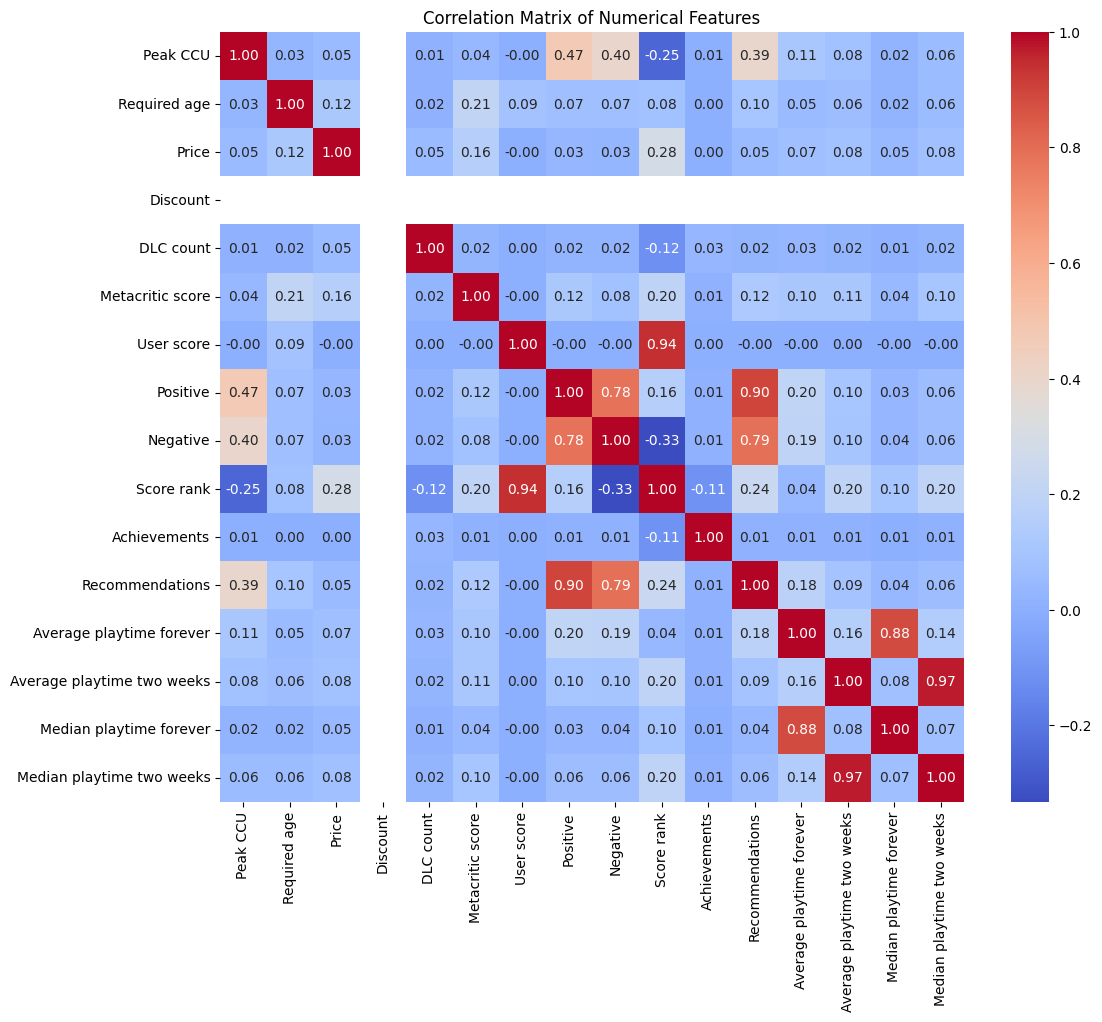

In [ ]:
# Defining seperate lists for numerical and categorical columns of steam_df
numerical_cols = steam_df.select_dtypes(include=['number']).columns
categorical_cols = steam_df.select_dtypes(exclude=['number']).columns

# Drop categorical columns
steam_df_numerical = steam_df.drop(columns=categorical_cols)

# Calculate correlation matrix
correlation_matrix = steam_df_numerical.corr()


# Create a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

## **Data Cleaning**

This is our 2nd iteration of Data cleaning for this dataset. In this iteration, we have done small changes in our original data cleaning approach to hopefully reduce the RMSE of our models.

When looking through our dataset, we had a few columns that we would not be able to use, such as Support Url and Screenshots, or columns with a lot of null values so we decided to drop them. Furthermore, we decided to drop all null values for now and then come back to them later.

In [ ]:
#Defining the list of columns to drop
col_to_be_dropped= ['About the game','Reviews','Website','Support url','Support email','Metacritic url','Header image','Score rank','Screenshots','Movies']

#Drop the unnecessary columns
steam_df=steam_df.drop(col_to_be_dropped,axis=1)

###Data Transformations###

Our dataset had a lot of categorical columns which would not go well with the models we covered in class. So we decided to transform the columns in the code below

####Redefining Columns####

For notes, we changed it into a binary column based on whether there was a note or not because we felt people(especially parents) would be more concerned if there is a note about a game than the type of note

In [ ]:
#Fill the null values in 'Notes'
steam_df['Notes'].fillna('No Notes',inplace=True)

#Transform notes into binary based on whether there was a note or not
steam_df['Notes'] = np.where(steam_df['Notes'] == 'No Notes', 0, 1)


<ipython-input-5-9a64b2c5c448>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  steam_df['Notes'].fillna('No Notes',inplace=True)


Dropping the Null values here, because we wanted to fill in the null Notes values first.

In [ ]:
#Dropping the null values from the dataset
steam_df=steam_df.dropna()

#Checking if any columns still have null values
steam_df.isnull().sum()

,0
Name,0
Release date,0
Estimated owners,0
Peak CCU,0
Required age,0
Price,0
Discount,0
DLC count,0
Supported languages,0
Full audio languages,0


For publishers and developers columns we had too many unique values. We decided to create aggregate grouping based on how many games the publishers and developers made. The reasoning is that with more games made, the publishers and developers would have more experience which would translate into a theoretically better game.

In [ ]:
# Group by publisher and count the number of games
publisher_game_counts = steam_df.groupby('Publishers')['Name'].count().reset_index()

# Rename the 'Name' column to 'Publisher Game Count'
publisher_game_counts = publisher_game_counts.rename(columns={'Name': 'Publisher Game Count'})

# Sort the table in descending order of Publisher Game Count
publisher_game_counts = publisher_game_counts.sort_values('Publisher Game Count', ascending=False)




# Merge the Publisher Game Counts back into the original DataFrame
steam_df = pd.merge(steam_df, publisher_game_counts, on='Publishers', how='left')

# Create the 'Publisher_type' column based on Publisher Game Counts.
def publisher_type(row):
    if row['Publisher Game Count'] == 1:
        return 'Publisher with 1 game'
    elif row['Publisher Game Count'] < 5: #5 games because that is around the average number of games that publishers with more than one game published
        return 'Publisher with a few games'
    else:
        return 'Publisher with a lot of games'

#Apply the function then drop the unnecessary columns
steam_df['Publisher_type'] = steam_df.apply(publisher_type, axis=1)
steam_df=steam_df.drop(['Publisher Game Count','Publishers'],axis=1)

In [ ]:
# Group by developer and count the number of games
developer_game_counts = steam_df.groupby('Developers')['Name'].count().reset_index()

# Rename the 'Name' column to 'Developer Game Count'
developer_game_counts = developer_game_counts.rename(columns={'Name': 'Developer Game Count'})

# Sort the table in descending order of Developer Game Count
developer_game_counts = developer_game_counts.sort_values('Developer Game Count', ascending=False)




# Merge the Developer Game Counts back into the original DataFrame
steam_df = pd.merge(steam_df, developer_game_counts, on='Developers', how='left')

# Create the 'Developer_type' column based on Developer Game Counts
def developer_type(row):
    if row['Developer Game Count'] == 1:
        return 'Developer with 1 game'
    elif row['Developer Game Count'] < 4:  # 4 games because that is the average number of games developed for developers with more than one game
        return 'Developer with a few games'
    else:
        return 'Developer with a lot of games'

#Apply the function then drop the unnecessary columns
steam_df['Developer_type'] = steam_df.apply(developer_type, axis=1)
steam_df=steam_df.drop(['Developer Game Count','Developers'],axis=1)

We have combined the Name and Estimated owners columns into one column called Large Established player base title because we felt that the biggest positive point about a game name is if there is a large player base that would play if a new game iteration would be realeased.

In [ ]:
#Define the new column
steam_df['Large Established player base title?'] = 0

#Give the column a value of 1 if the estimated owners column is in the larger values for estimated owners
steam_df.loc[steam_df['Estimated owners'].isin(['5000000 - 10000000', '10000000 - 20000000',
       '50000000 - 100000000', '100000000 - 200000000']), 'Large Established player base title?'] = 1

#Drop the Name and Estimated owners columns
steam_df=steam_df.drop(['Name','Estimated owners'],axis=1)

For the Release Date column, our models may have a problem reading the datetime format, which is why we decided to redefine the column as Years Old. We feel that the age of the game is the most important factor from the Release Date column.

In [ ]:
#Extract the Year of release for the games from the Release date column
steam_df['Release Year'] = pd.to_datetime(steam_df['Release date'], errors='coerce', format='mixed').dt.year

# Calculate the 'Years old' column
steam_df['Years old'] = 2025 - steam_df['Release Year']

# Drop the original 'Release date' column
steam_df = steam_df.drop(['Release date', 'Release Year'], axis=1)

Finally, we created a predictor column positive% based on the number of positive reviews over the number of total reviews(positive+negative).

In [ ]:
steam_df['Positive%'] = steam_df['Positive'] / (steam_df['Positive'] + steam_df['Negative']) * 100
steam_df=steam_df.drop(['Positive','Negative'],axis=1)
steam_df.head()

,Peak CCU,Required age,Price,Discount,DLC count,Supported languages,Full audio languages,Windows,Mac,Linux,Metacritic score,User score,Achievements,Recommendations,Notes,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Categories,Genres,Tags,Publisher_type,Developer_type,Large Established player base title?,Years old,Positive%
0,0,0,19.99,0,0,['English'],[],True,False,False,0,0,30,0,0,0,0,0,0,"Single-player,Multi-player,Steam Achievements,...","Casual,Indie,Sports","Indie,Casual,Sports,Bowling",Publisher with 1 game,Developer with 1 game,0,17,35.294118
1,0,0,0.99,0,0,"['English', 'French', 'Italian', 'German', 'Sp...",[],True,True,False,0,0,12,0,0,0,0,0,0,"Single-player,Steam Achievements,Full controll...","Action,Indie","Indie,Action,Pixel Graphics,2D,Retro,Arcade,Sc...",Publisher with a lot of games,Developer with a lot of games,0,8,91.379310
2,0,0,5.99,0,0,"['English', 'French', 'Italian', 'German', 'Sp...",[],True,True,True,0,0,0,0,0,0,0,0,0,"Single-player,Full controller support","Adventure,Casual,Indie","2D Platformer,Atmospheric,Surreal,Mystery,Puzz...",Publisher with 1 game,Developer with 1 game,0,5,100.000000
3,0,0,0.00,0,0,"['English', 'Spanish - Spain']",[],True,True,False,0,0,17,0,1,0,0,0,0,"Single-player,Steam Achievements","Adventure,Indie","Indie,Adventure,Nudity,Violent,Sexual Content,...",Publisher with 1 game,Developer with 1 game,0,5,86.206897
4,68,0,0.00,0,0,['English'],[],True,False,False,0,0,0,0,0,0,0,0,0,"Single-player,Multi-player,MMO,PvP,Online PvP,...","Adventure,Casual,Free to Play,Massively Multip...","Turn-Based Combat,Massively Multiplayer,Multip...",Publisher with 1 game,Developer with 1 game,0,4,63.970588


####Creating Dummy columns####

For our categorical columns, we have decided to create dummy variables for at least the most prominent categories in those columns.

When creating dummies for our supported languages and audio languges columns, there would be a lot of confusing symbols inside them so we decided to remove each of type of weird simple for both columns with the code below. Then we saw that all of the languages in the rows were in a list format, so we split them by ','. Finally, we created the dummies for these columns.

In [ ]:
# Removing weird symbols for Supported languages column
steam_df['Supported languages'] = steam_df['Supported languages'].str.replace('[', '', regex=False)
steam_df['Supported languages'] = steam_df['Supported languages'].str.replace(']', '', regex=False)
steam_df['Supported languages'] = steam_df['Supported languages'].str.replace("'", '', regex=False)
steam_df['Supported languages'] = steam_df['Supported languages'].str.replace("\r\n\r\nb/b", '', regex=False)
steam_df['Supported languages'] = steam_df['Supported languages'].str.replace("(all with full audio support)", '', regex=False)
steam_df['Supported languages'] = steam_df['Supported languages'].str.replace("&amp;lt;br /&amp;gt;&amp;lt;br /&amp;gt;&amp;lt;strong&amp;gt;&amp;lt;/strong&amp;gt", '', regex=False)
steam_df['Supported languages'] = steam_df['Supported languages'].str.replace("/b", '', regex=False)
steam_df['Supported languages'] = steam_df['Supported languages'].str.replace(";", '', regex=False)
steam_df['Supported languages'] = steam_df['Supported languages'].str.replace("&amp;lt;strong&amp;gt;&amp;lt;/strong&amp;gt;", '', regex=False)
steam_df['Supported languages'] = steam_df['Supported languages'].str.replace("\r\n\r\nb", '', regex=False)
steam_df['Supported languages'] = steam_df['Supported languages'].str.replace("\r\nb", '', regex=False)
steam_df['Supported languages'] = steam_df['Supported languages'].str.replace("\r\n", '', regex=False)
steam_df['Supported languages'] = steam_df['Supported languages'].str.replace("-", '', regex=False)
steam_df['Supported languages'] = steam_df['Supported languages'].str.replace("&ampltstrong&ampgt&amplt/strong&ampgt", '', regex=False)
steam_df['Supported languages'] = steam_df['Supported languages'].str.replace("&ampltstrong&ampgt&amplt/strong&ampgt", '', regex=False)
steam_df['Supported languages'] = steam_df['Supported languages'].str.replace("\r", '', regex=False)



#Removing weird symbols for Full audio language column
steam_df['Full audio languages'] = steam_df['Full audio languages'].str.replace('[', '', regex=False)
steam_df['Full audio languages'] = steam_df['Full audio languages'].str.replace(']', '', regex=False)
steam_df['Full audio languages'] = steam_df['Full audio languages'].str.replace("'", '', regex=False)
steam_df['Full audio languages'] = steam_df['Full audio languages'].str.replace("\r\n\r\nb/b", '', regex=False)
steam_df['Full audio languages'] = steam_df['Full audio languages'].str.replace("(all with full audio support)", '', regex=False)
steam_df['Full audio languages'] = steam_df['Full audio languages'].str.replace("&amp;lt;br /&amp;gt;&amp;lt;br /&amp;gt;&amp;lt;strong&amp;gt;&amp;lt;/strong&amp;gt", '', regex=False)
steam_df['Full audio languages'] = steam_df['Full audio languages'].str.replace("/b", '', regex=False)
steam_df['Full audio languages'] = steam_df['Full audio languages'].str.replace(";", '', regex=False)
steam_df['Full audio languages'] = steam_df['Full audio languages'].str.replace("&amp;lt;strong&amp;gt;&amp;lt;/strong&amp;gt;", '', regex=False)
steam_df['Full audio languages'] = steam_df['Full audio languages'].str.replace("\r\n\r\nb", '', regex=False)
steam_df['Full audio languages'] = steam_df['Full audio languages'].str.replace("\r\nb", '', regex=False)
steam_df['Full audio languages'] = steam_df['Full audio languages'].str.replace("\r\n", '', regex=False)
steam_df['Full audio languages'] = steam_df['Full audio languages'].str.replace("-", '', regex=False)
steam_df['Full audio languages'] = steam_df['Full audio languages'].str.replace("&ampltstrong&ampgt&amplt/strong&ampgt", '', regex=False)
steam_df['Full audio languages'] = steam_df['Full audio languages'].str.replace("&ampltstrong&ampgt&amplt/strong&ampgt", '', regex=False)
steam_df['Full audio languages'] = steam_df['Full audio languages'].str.replace("\r", '', regex=False)
steam_df['Full audio languages'] = steam_df['Full audio languages'].str.replace(" ", '', regex=False)


#Splitting the different languages in the rows of these columns
steam_df['Supported languages'] = steam_df['Supported languages'].str.split(',')
steam_df['Full audio languages'] = steam_df['Full audio languages'].str.split(',')


# Create dummy variables for supported languages and drop the original column
languages_df = steam_df['Supported languages'].str.join('|').str.get_dummies()
steam_df = pd.concat([steam_df, languages_df], axis=1)
steam_df = steam_df.drop('Supported languages', axis=1)


# Create dummy variables for 'Full audio languages' and drop the original column
full_audio_languages_df = steam_df['Full audio languages'].str.join('|').str.get_dummies()
full_audio_languages_df = full_audio_languages_df.add_suffix('_Audio') #To differentiate these dummies from the ones in supported languages
steam_df = pd.concat([steam_df, full_audio_languages_df], axis=1)
steam_df = steam_df.drop('Full audio languages', axis=1)


After creating all the dummies, there were too many columns for our dataset, so we decided to remove some of them. For this purpose, we created tables representing the frequencies of each dummy columns(separate for supported languages and full audio languages columns), and then we chose the top 10 among them because we felt that those make the most sense. Furthermore, we created a column that counts the number of languages that were not in the top 10, because we felt that a game that had many other languages would have different ratings than ones with a low number of other languages.

In [ ]:
#The code below is for Full audio languages dummies

#Create a seperate dataframe for audio language column and calculate the frequencies
audio_language_columns = [col for col in steam_df.columns if col.endswith('_Audio')]
audio_language_frequencies = steam_df[audio_language_columns].sum().sort_values(ascending=False)

#Define the frequencies in a tbale with their associated language and extract top 10 columns
audio_language_frequency_table = pd.DataFrame({'Audio Language': audio_language_frequencies.index, 'Frequency': audio_language_frequencies.values})
top_10_audio_languages = audio_language_frequency_table['Audio Language'].head(10).tolist()

#Define Other Audio Langauges and asign it 0 or 1 if there is another language outside of top 10
steam_df['Other_Audio_languages'] = 0

for col in steam_df.columns:
  if col not in top_10_audio_languages and col in audio_language_frequencies.index:
    steam_df['Other_Audio_languages'] = steam_df['Other_Audio_languages'] + steam_df[col].astype(int)

# Identify columns to drop (all audio language columns except top 10) and drop them
columns_to_drop_audio = [col for col in steam_df.columns if col not in top_10_audio_languages and col.endswith('_Audio')]
steam_df = steam_df.drop(columns=columns_to_drop_audio)





#The code below is for Supported languages dummies

numerical_cols = steam_df.iloc[:, (-languages_df.shape[1]-13):].select_dtypes(include=np.number).columns
language_frequencies = steam_df[numerical_cols].sum().sort_values(ascending=False)


# Calculate language frequencies and create a table for it

language_frequency_table = pd.DataFrame({'Language': language_frequencies.index, 'Frequency': language_frequencies.values})

#Create the frequency table while making sure to avoid the Auido dummy variables
language_frequency_table = language_frequency_table[~language_frequency_table['Language'].str.endswith('_Audio')]
language_frequency_table = language_frequency_table[~language_frequency_table['Language'].str.endswith('Other_Audio_Languages')]
language_frequency_table = language_frequency_table[~language_frequency_table['Language'].str.endswith('Positive%')]
language_frequency_table = language_frequency_table[~language_frequency_table['Language'].str.endswith('Years old')]
# Get the top 10 languages
top_10_languages = language_frequency_table['Language'].head(10).tolist()

#Initiate the Other languages column and asign it either 1 or 0 based on whether there is another language
steam_df['Other languages'] = 0

for col in steam_df.columns:
  if col not in top_10_languages and col in language_frequencies.index:
    steam_df['Other languages'] = steam_df['Other languages'] + steam_df[col].astype(int) #astype(int) to fix error with numerical column being a float

#Identify columns to drop (all language columns except top 10)
#Exclude columns that end with _Audio
columns_to_drop = [col for col in steam_df.columns if col not in top_10_languages and col in language_frequencies.index and not col.endswith('_Audio') and col not in ['Other_Audio_Languages','Developer_type','Publisher_type', 'Years old','Positive%']]

# Drop the languages dummies outside of top 10 columns
steam_df = steam_df.drop(columns=columns_to_drop)

Our publisher and developer type columns have text in them, so we created dummies on them for models.

In [ ]:
# Dummy variables for 'Publisher_type'
publisher_dummies = pd.get_dummies(steam_df['Publisher_type'], prefix='Publisher')
steam_df = pd.concat([steam_df, publisher_dummies], axis=1)
steam_df = steam_df.drop('Publisher_type', axis=1)

# Dummy variables for 'Developer_type'
developer_dummies = pd.get_dummies(steam_df['Developer_type'], prefix='Developer')
steam_df = pd.concat([steam_df, developer_dummies], axis=1)
steam_df = steam_df.drop('Developer_type', axis=1)

For the Categories, Genres, and Tags columns we created dummy variables but found that it would lead to too many columns in our dataset. To resolve the issue, we decided to use the frequencies of those dummy columns. More specifically, we would remove any dummy column that had a frequency that was below the average frequency for its given type(Category, Genre, or Tag). However, for tags, we still had too many columns, so we decided to be more strict for that column and only included those tag dummies that had a frequency above a 10,000 into our dataset.

In [ ]:
#Spliting the values in Categories, Genres, and Tags because they were in list format
steam_df['Categories'] = steam_df['Categories'].str.split(',')
steam_df['Genres'] = steam_df['Genres'].str.split(',')
steam_df['Tags'] = steam_df['Tags'].str.split(',')


#The function creates the dummies and ads the column prefix to each dummy so that we can differentiate between them
def create_dummy_variables(df, column_name):
    dummy_df = df[column_name].apply(pd.Series).stack().str.get_dummies().groupby(level=0).sum() # Changed this line
    dummy_df = dummy_df.add_prefix(f'{column_name}_')
    return pd.concat([df, dummy_df], axis=1).drop(column_name, axis=1)

#Applies the function on each of the 3 columns
steam_df = create_dummy_variables(steam_df, 'Categories')
steam_df = create_dummy_variables(steam_df, 'Genres')
steam_df = create_dummy_variables(steam_df, 'Tags')





# Calculate frequency for each dummy column (Categories, Genres, Tags)
def calculate_frequency(df, column_prefix):
    columns = [col for col in df.columns if col.startswith(column_prefix)]
    frequency = df[columns].sum().sort_values(ascending=False)
    return pd.DataFrame({'Category': frequency.index, 'Frequency': frequency.values})




# Categories frequency table
categories_frequency_table = calculate_frequency(steam_df, 'Categories_')
print("Categories Frequency Table:")

print("\n")

# Genres frequency table
genres_frequency_table = calculate_frequency(steam_df, 'Genres_')
print("Genres Frequency Table:")

print("\n")

# Tags frequency table
tags_frequency_table = calculate_frequency(steam_df, 'Tags_')
print("Tags Frequency Table:")


# Calculate average frequencies
categories_average_frequency = categories_frequency_table['Frequency'].mean()
genres_average_frequency = genres_frequency_table['Frequency'].mean()
tags_average_frequency = tags_frequency_table['Frequency'].mean()

# Remove columns below average frequency
def remove_below_average(df, frequency_table, average_frequency, prefix):
    columns_to_remove = frequency_table[frequency_table['Frequency'] < average_frequency]['Category'].tolist()

    print(columns_to_remove)
    return df.drop(columns=columns_to_remove)

#Apply the function
steam_df = remove_below_average(steam_df, categories_frequency_table, categories_average_frequency, 'Categories_')
steam_df = remove_below_average(steam_df, genres_frequency_table, genres_average_frequency, 'Genres_')
steam_df = remove_below_average(steam_df, tags_frequency_table, tags_average_frequency, 'Tags_')


# Filter out tags with frequency below 10,000
tags_to_keep = tags_frequency_table[tags_frequency_table['Frequency'] >= 10000]['Category'].tolist()

# Get all tag columns
all_tag_columns = [col for col in steam_df.columns if col.startswith('Tags_')]

# Identify tag columns to remove
tag_columns_to_remove = [col for col in all_tag_columns if col not in tags_to_keep]

# Drop the identified tag columns
steam_df = steam_df.drop(columns=tag_columns_to_remove)

Categories Frequency Table:


Genres Frequency Table:


Tags Frequency Table:
['Categories_Remote Play Together', 'Categories_Shared/Split Screen', 'Categories_Online Co-op', 'Categories_Shared/Split Screen PvP', 'Categories_Stats', 'Categories_Family Sharing', 'Categories_Shared/Split Screen Co-op', 'Categories_Remote Play on TV', 'Categories_Cross-Platform Multiplayer', 'Categories_Includes level editor', 'Categories_Steam Workshop', 'Categories_In-App Purchases', 'Categories_Captions available', 'Categories_Remote Play on Tablet', 'Categories_MMO', 'Categories_Remote Play on Phone', 'Categories_LAN PvP', 'Categories_LAN Co-op', 'Categories_VR Only', 'Categories_VR Support', 'Categories_Commentary available', 'Categories_Tracked Controller Support', 'Categories_Valve Anti-Cheat enabled', 'Categories_Steam Turn Notifications', 'Categories_VR Supported', 'Categories_Includes Source SDK', 'Categories_SteamVR Collectibles', 'Categories_HDR available', 'Categories_Mods', 'Categories_Mods 

## **Regression Model Testing**

Below are the models we have decided to use for our analysis.

In [ ]:
X=steam_df.drop(['Positive%'],axis=1)
y=steam_df['Positive%']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=1)

print(X.shape)
print(X.dtypes)

(66230, 77)
Peak CCU               int64
Required age           int64
Price                float64
Discount               int64
DLC count              int64
                      ...   
Tags_Puzzle            int64
Tags_RPG               int64
Tags_Simulation        int64
Tags_Singleplayer      int64
Tags_Strategy          int64
Length: 77, dtype: object


###Benchmark

In [ ]:
import math
# Calculate the average of 'Positive%' in y_train
average_positive_percentage_train = y_train.mean()

# Predict all values in y_test as the average of y_train
predictions = [average_positive_percentage_train] * len(y_test)

print(average_positive_percentage_train)

# Calculate RMSE
rmse = math.sqrt(mean_squared_error(y_test, predictions))
print(f"RMSE using average of y_train: {rmse}")
print(predictions)

75.730885474854
RMSE using average of y_train: 24.618334731704064
[np.float64(75.730885474854), np.float64(75.730885474854), np.float64(75.730885474854), np.float64(75.730885474854), np.float64(75.730885474854), np.float64(75.730885474854), np.float64(75.730885474854), np.float64(75.730885474854), np.float64(75.730885474854), np.float64(75.730885474854), np.float64(75.730885474854), np.float64(75.730885474854), np.float64(75.730885474854), np.float64(75.730885474854), np.float64(75.730885474854), np.float64(75.730885474854), np.float64(75.730885474854), np.float64(75.730885474854), np.float64(75.730885474854), np.float64(75.730885474854), np.float64(75.730885474854), np.float64(75.730885474854), np.float64(75.730885474854), np.float64(75.730885474854), np.float64(75.730885474854), np.float64(75.730885474854), np.float64(75.730885474854), np.float64(75.730885474854), np.float64(75.730885474854), np.float64(75.730885474854), np.float64(75.730885474854), np.float64(75.730885474854), np.fl

###KNN-regressor

In [ ]:
from sklearn.neighbors import KNeighborsRegressor


# Standardize the data
scaler = preprocessing.StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train the KNN regressor with scaled data
knn_regressor_scaled = KNeighborsRegressor(n_neighbors=20) # You can adjust the number of neighbors
knn_regressor_scaled.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
y_pred_scaled = knn_regressor_scaled.predict(X_test_scaled)

# Calculate RMSE for the scaled data
rmse_scaled = math.sqrt(mean_squared_error(y_test, y_pred_scaled))
print(f"KNN RMSE (Scaled Data): {rmse_scaled}")


KNN RMSE (Scaled Data): 15.17399883639635


###Decision Trees

In [ ]:
from sklearn.tree import DecisionTreeRegressor



# Initialize and train the decision tree regressor
dt_regressor = DecisionTreeRegressor(random_state=1)  # You can tune hyperparameters here
dt_regressor.fit(X_train, y_train)

# Make predictions on the test set
y_pred = dt_regressor.predict(X_test)

# Evaluate the model
rmse = math.sqrt(mean_squared_error(y_test, y_pred))
print(f"Decision Tree RMSE: {rmse}")

# You can further tune the hyperparameters of the decision tree using GridSearchCV
# for better performance.


Decision Tree RMSE: 2.43209183189157


In [ ]:
# prompt: Can you scale the data before running decision trees?

import numpy as np
# Assuming X_train and X_test are your training and testing dataframes respectively.
# Also assuming you want to scale only the numerical features

from sklearn.preprocessing import StandardScaler

# Identify numerical features
numerical_cols = X_train.select_dtypes(include=np.number).columns

# Scale numerical features
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

# Now use X_train_scaled and X_test_scaled for your decision tree model
dt_regressor = DecisionTreeRegressor(random_state=1)
dt_regressor.fit(X_train_scaled, y_train)
y_pred = dt_regressor.predict(X_test_scaled)
rmse = math.sqrt(mean_squared_error(y_test, y_pred))
print(f"Decision Tree RMSE (Scaled Data): {rmse}")


Decision Tree RMSE (Scaled Data): 2.4302748052687355


In [ ]:
# prompt: Can you run a cross validation test to hypertune the parameters in the decision tree?

# Define the parameter grid for hyperparameter tuning
param_grid = {
    'max_depth': [None, 10, 20, 30,40,50],
    'min_samples_split': [2, 5, 10,20],
    'min_samples_leaf': [1, 2, 4,8]
}

# Initialize the decision tree regressor
dt_regressor = DecisionTreeRegressor(random_state=1)

# Perform GridSearchCV for hyperparameter tuning
grid_search = GridSearchCV(estimator=dt_regressor, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train_scaled, y_train)

# Get the best hyperparameters and the best model
best_params = grid_search.best_params_
best_dt_regressor = grid_search.best_estimator_

print(f"Best Hyperparameters: {best_params}")

# Evaluate the best model on the test set
y_pred = best_dt_regressor.predict(X_test_scaled)
rmse = math.sqrt(mean_squared_error(y_test, y_pred))
print(f"Decision Tree RMSE (Scaled Data, Tuned): {rmse}")


Best Hyperparameters: {'max_depth': 20, 'min_samples_leaf': 4, 'min_samples_split': 20}
Decision Tree RMSE (Scaled Data, Tuned): 2.156304045607756


###Random Forest and Feature Importance

In [ ]:
# prompt: Can you run random forests on the data? and give the rmse of that?

from sklearn.ensemble import RandomForestRegressor

# Assuming X_train_scaled, X_test_scaled, y_train, and y_test are defined from previous code

# Initialize and train the random forest regressor
rf_regressor = RandomForestRegressor(random_state=1, n_estimators=100)  # You can adjust the number of estimators and other hyperparameters
rf_regressor.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_rf = rf_regressor.predict(X_test_scaled)

# Calculate RMSE for the random forest model
rmse_rf = math.sqrt(mean_squared_error(y_test, y_pred_rf))
print(f"Random Forest RMSE (Scaled Data): {rmse_rf}")


Random Forest RMSE (Scaled Data): 1.658517518981883


In [ ]:
# prompt: Can you print out the importance of each column based on the random forest above?

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import math

# Assuming X and y are defined as in the previous code
# X = steam_df_cleaned.drop('Positive%', axis=1)
# y = steam_df_cleaned['Positive%']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=1)

# Identify numerical features
numerical_cols = X_train.select_dtypes(include=np.number).columns

# Scale numerical features
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

# Initialize and train the random forest regressor
rf_regressor = RandomForestRegressor(random_state=1, n_estimators=100)  # You can adjust the number of estimators and other hyperparameters
rf_regressor.fit(X_train_scaled, y_train)

# Get feature importances
importances = rf_regressor.feature_importances_

# Create a DataFrame to display feature importances
feature_importances = pd.DataFrame({'Feature': X_train_scaled.columns, 'Importance': importances})
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)
feature_importances


,Feature,Importance
39,Other languages,9.780631e-01
18,Years old,8.184376e-03
38,Other_Audio_languages,2.766141e-03
21,Italian,1.656022e-03
13,Average playtime forever,1.204863e-03
...,...,...
14,Average playtime two weeks,1.024762e-05
5,Windows,6.873757e-06
9,User score,1.600693e-06
17,Large Established player base title?,5.555524e-07


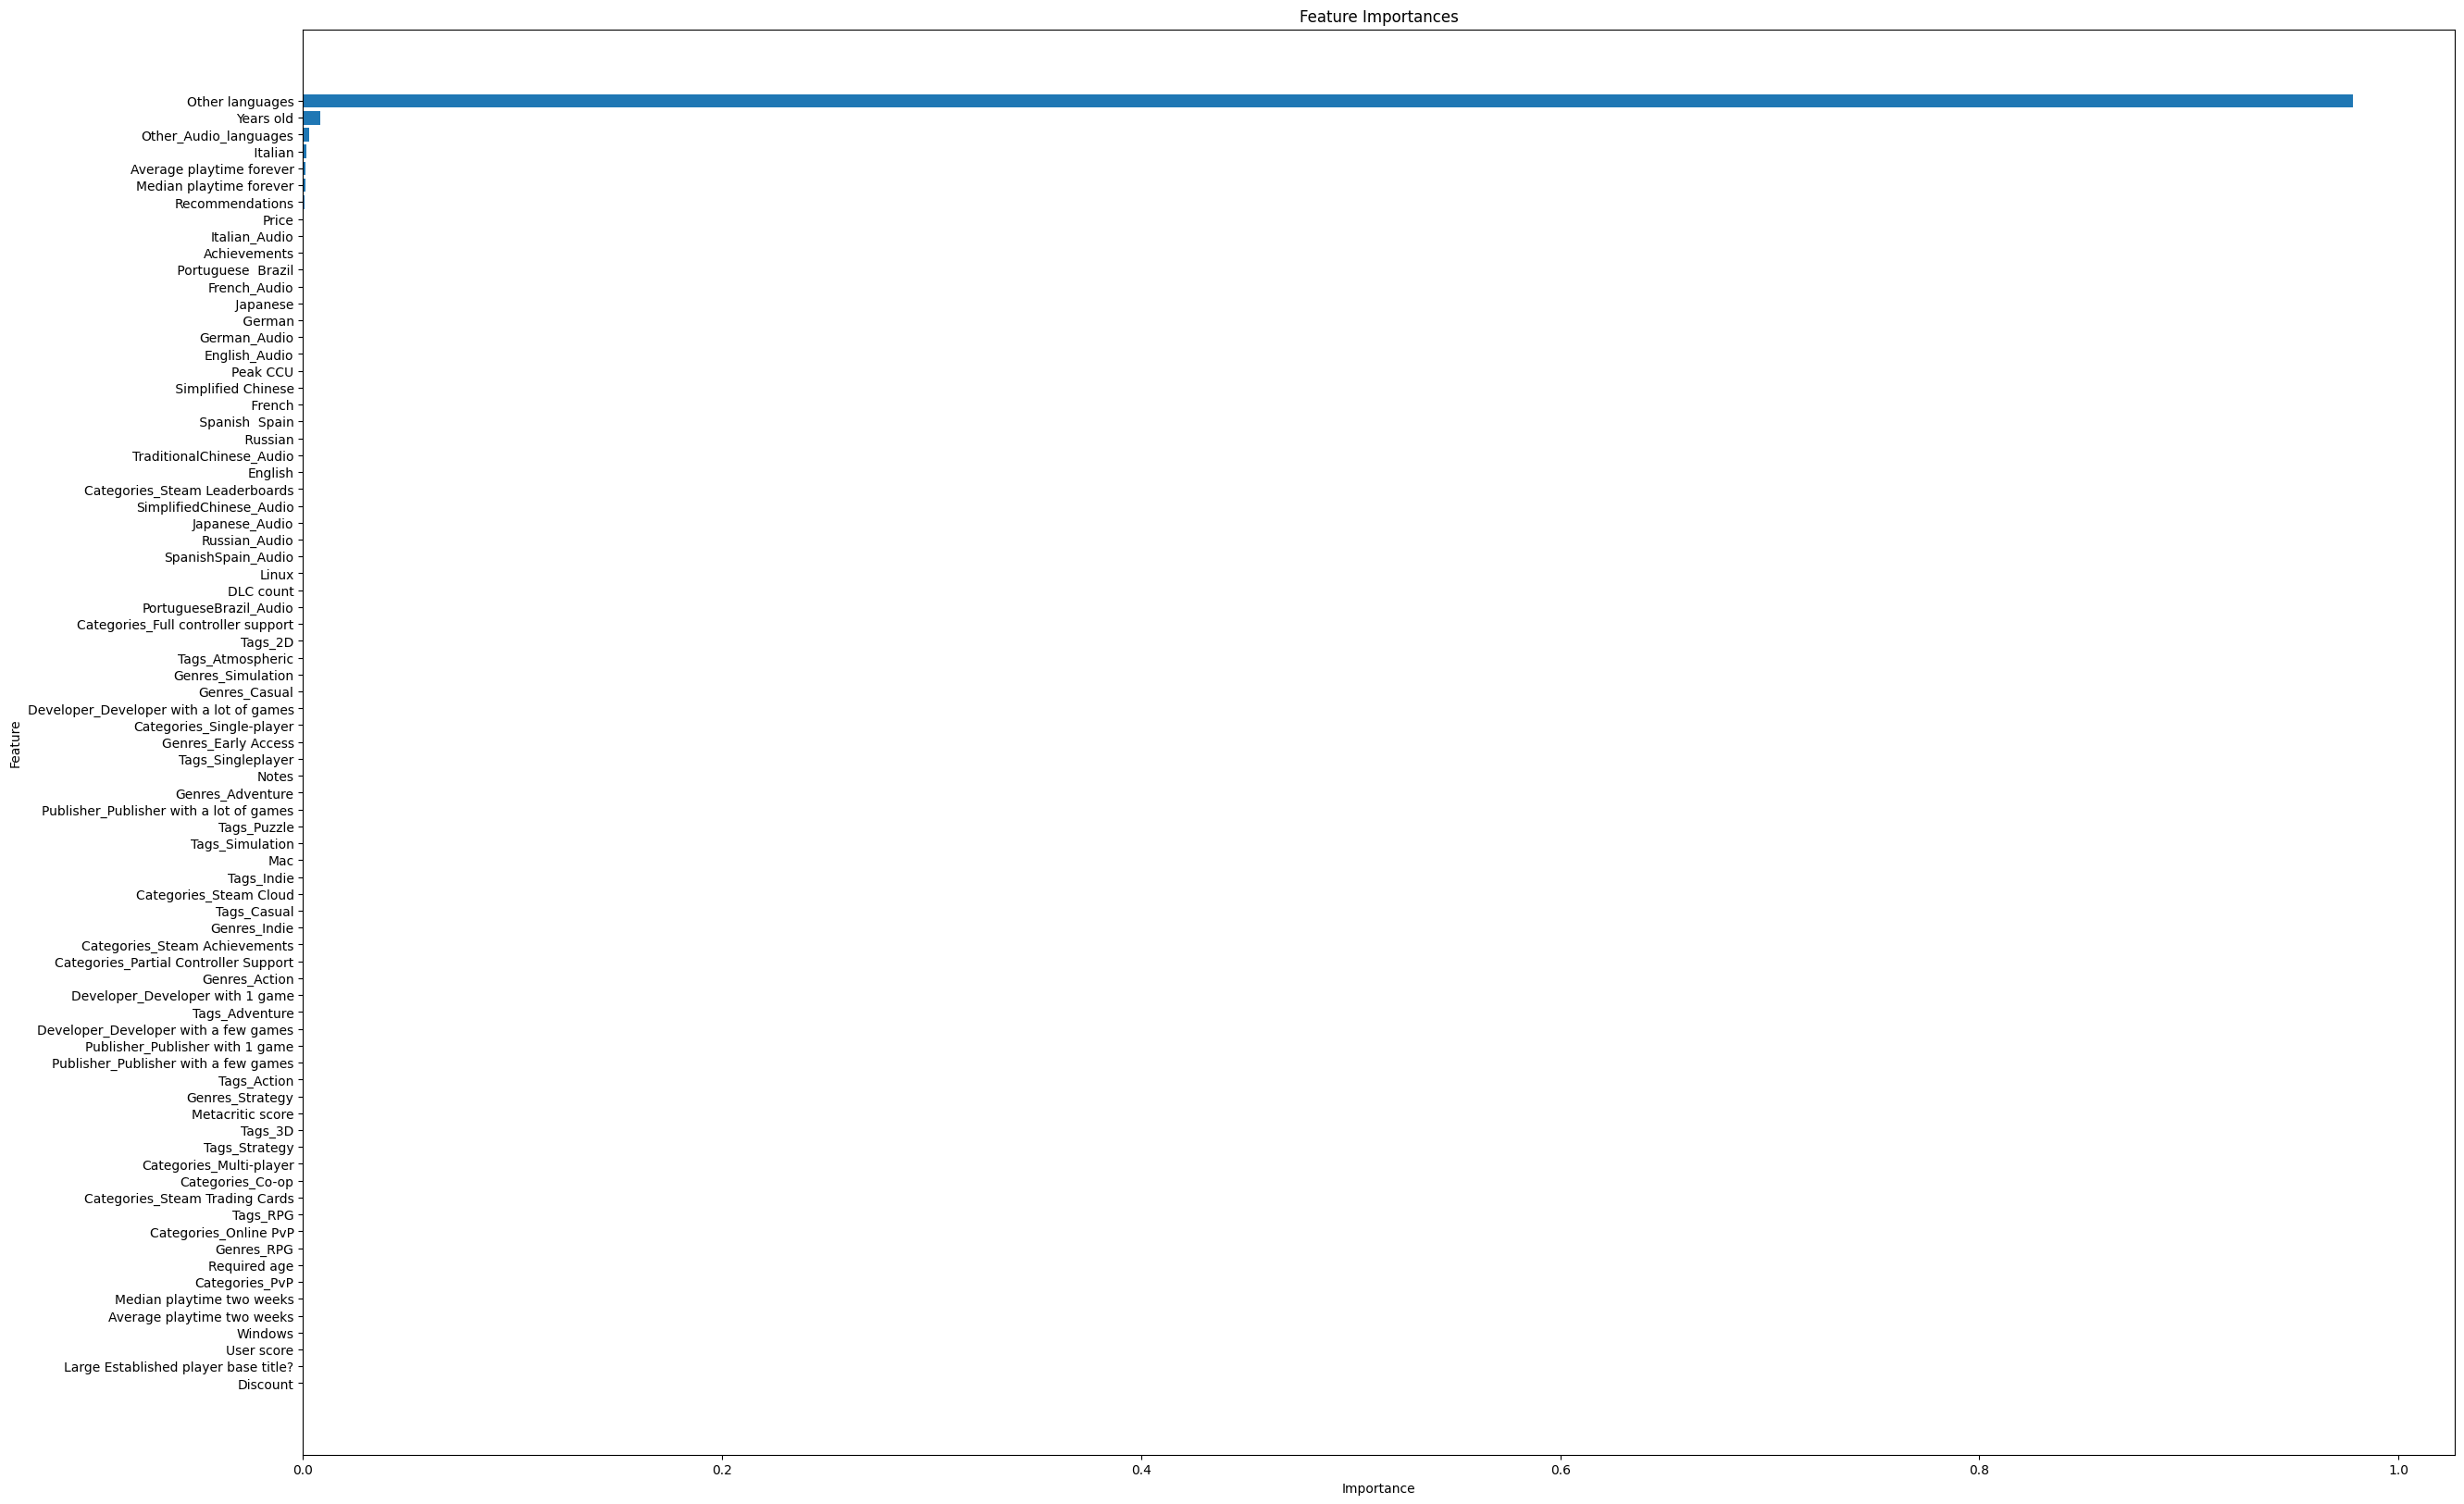

In [ ]:
# prompt: Can you visualize out the feature importances?

import matplotlib.pyplot as plt

# Assuming feature_importances DataFrame is defined as in the previous code

plt.figure(figsize=(30, 20))
plt.barh(feature_importances['Feature'], feature_importances['Importance'])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importances")
plt.gca().invert_yaxis()  # Invert y-axis to display the most important features at the top
plt.show()


###Linear Regression

In [ ]:
# prompt: Can you also run a linear regression model and determine its rmse?(be sure to scale the data again)

from sklearn.linear_model import LinearRegression

# Assuming X_train_scaled, X_test_scaled, y_train, and y_test are defined from previous code

# Initialize and train the linear regression model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_lr = lr_model.predict(X_test_scaled)

# Calculate RMSE for the linear regression model
rmse_lr = math.sqrt(mean_squared_error(y_test, y_pred_lr))
print(f"Linear Regression RMSE (Scaled Data): {rmse_lr}")


Linear Regression RMSE (Scaled Data): 2.0280716069403253


###XGboost

In [ ]:
# prompt: Can you apply the XGboost model now?and show the rmse please

!pip install xgboost

import xgboost as xgb
from sklearn.metrics import mean_squared_error
import math

# Assuming X_train_scaled, X_test_scaled, y_train, and y_test are defined from previous code

# Initialize and train the XGBoost regressor
xgb_regressor = xgb.XGBRegressor(objective='reg:squarederror', random_state=1) # Use reg:squarederror for regression
xgb_regressor.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_xgb = xgb_regressor.predict(X_test_scaled)

# Calculate RMSE for the XGBoost model
rmse_xgb = math.sqrt(mean_squared_error(y_test, y_pred_xgb))
print(f"XGBoost RMSE (Scaled Data): {rmse_xgb}")


XGBoost RMSE (Scaled Data): 1.4857009358470246


###Neural Network

In [ ]:
# prompt: Can you now apply a neural network model while also showing the rmse?(Using mlpregressor)

from sklearn.neural_network import MLPRegressor

# Assuming X_train_scaled, X_test_scaled, y_train, and y_test are defined from previous code

# Initialize and train the MLPRegressor
mlp_regressor = MLPRegressor(hidden_layer_sizes=(10), max_iter=1000, activation='logistic',solver='lbfgs', random_state=1) # Adjust hidden_layer_sizes and other hyperparameters as needed
mlp_regressor.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_mlp = mlp_regressor.predict(X_test_scaled)

# Calculate RMSE for the MLPRegressor model
rmse_mlp = math.sqrt(mean_squared_error(y_test, y_pred_mlp))
print(f"MLPRegressor RMSE (Scaled Data): {rmse_mlp}")


MLPRegressor RMSE (Scaled Data): 1.4780755116131128


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


##Identifying Why Other Languages leads to such great predictions

When running the model we found that Other languages had significantly high predictive power(around 98.8%) completely shutting out all of the other columns. However, this implies that factors like price, game reviews and etc. do not matter, and all that matters is how many other languags the game has(languages outside of the top 10). However, in the real world that does not make sense, because if a game is bad, people will hate it even if it is available in their langauge. 2. After finding the correlation, we have decided that this is a mere coincidence. To further verify this, in later iterations we have created a column with the total number of languages and the predictor did not dominate the others, so we can be comfortable with saying this was a mere chance

Correlation between Other languages and Positive%: 0.9817120244465072


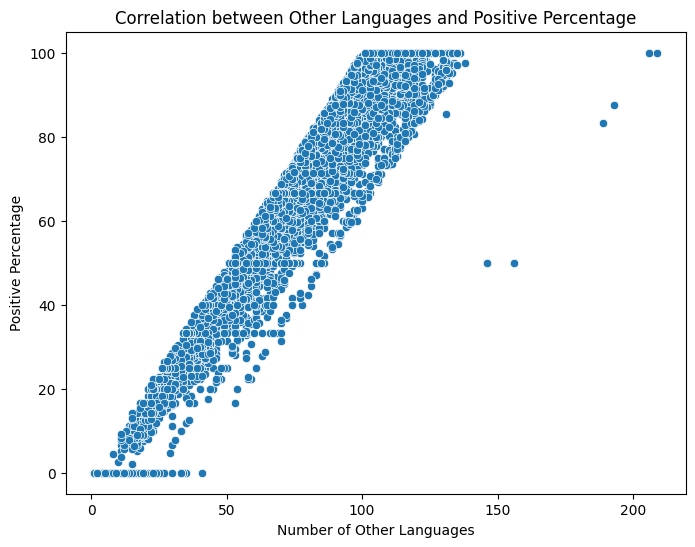

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'steam_df' is your DataFrame
# Calculate the correlation between 'Other_languages' and 'Positive%'
correlation = steam_df['Other languages'].corr(steam_df['Positive%'])
print(f"Correlation between Other languages and Positive%: {correlation}")

# Create a scatter plot to visualize the relationship
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Other languages', y='Positive%', data=steam_df)
plt.title('Correlation between Other Languages and Positive Percentage')
plt.xlabel('Number of Other Languages')
plt.ylabel('Positive Percentage')
plt.show()


Upon further reflection after our presentation, we have found some other more qualitative reasons as to why the other languages column works so well for predicting Positive%. The top 10 languages occur in most of the games, meaning they are not varied across games. However, few games have languages outside the top 10, leading to more variance in the distribution.

Furthermore, we speculate that this other languages column represents other information that is not directly linked to the number of other languages. For example, a factor influencing this could be the scale of the game because the games that have languages outside the top 10 are commonly high-scale(AAA) global games. Other reasons could be Developer updates(as games that get more languages could have more updates to fix bugs and other issues) and game large audience appeal(games would not get high languages support if there was no global audience appeal).


As to why these apply more to other languages and not total numbner of languages, we developed 2 reasons. First, because most games have the top languages, languages are counted for many games creating extra noise. Second, other languages could furher strengthen the qualitative reasons stated in the previous paragraph, because most game would still apply to the first 10 languages, but only a few would appeal to more niche ones.

In conclusion, we still dropped the other languages column because it still might be just a coincidence or it may leeking some other information, examples of which are listed aove. Since we do not have access to this other information, we still decided to go with our later appraoches.